## (a) Creating epochs from cleaned raw files

Now that the raw data has been cleaned, the next step is to create **epochs**—segments of EEG data time-locked to specific events. This is done to isolate the neural responses to specific stimuli and exclude unrelated portions of the recording.

### Finding events

The `find_events` function extracts all the recorded events from the stim channel named in `config['channels']['stim_channel']` — on a BioSemi system this is the `Status` channel. These events correspond to the triggers recorded during the experiment, indicating when specific stimuli or actions occurred. As you can see in the output of this function, there are other triggers present in the data, but they are not crucial for this analysis.

### Creating epochs

Using the `Epochs` class, the cleaned data is segmented into epochs. Here's an explanation of the key parameters, all read from `config['epochs']` so they can be **fully adapted to your own trigger scheme**:
- **`events`**: The extracted events from the stim channel.
- **`event_id`**: A dict mapping a label to the trigger code(s) of interest — `{'sentence onset': 256}` here, since the trigger code 256 marks the onset of speech. "Soft triggers" were used, so the same code (256) was used for every trial, independent of the experimental condition. If your paradigm uses different codes per condition, add more entries to this dict.
- **`tmin=-0.200`**: Includes 200 ms of data before the stimulus onset as a baseline period. This is a standard choice for EEG analyses to capture pre-stimulus activity.
- **`tmax=7.000`**: Captures 7 seconds of data following the stimulus onset. This duration was chosen because the sentences in the experiment had an average length of 7 seconds, ensuring the epochs cover the entire stimulus duration. Set `tmax` to cover the longest window any of your downstream analyses need — individual analyses can always crop back down (see the AEP step below), but they can't recover data outside the original epoch.
- **`baseline=(-0.200, 0)`**: Sets a baseline correction window from -200 to 0 ms to account for drift or other slow fluctuations in the data.

This step creates time-locked epochs that align the EEG signals to the presentation of each stimulus, preparing the data for further analyses.

As you can seen from the output, there are 120 epochs, which correspond to the 120 sentences presented in the experiment.

In [1]:
import json
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from pathlib import Path

# mne.set_log_level('WARNING')  # suppresses MNE messages; only show warnings and errors; activate if you want to see all messages

# Load researcher/setup-specific settings (shared with notebook 1). Edit config.json, not this cell, to adapt this tutorial to your own data.
try:
    with open('config.json') as f:
        config = json.load(f)
except json.JSONDecodeError as e:
    raise ValueError(
        f"config.json has invalid JSON syntax: {e}\n"
        "Common causes: a trailing comma after the last item in a list/object, "
        "single quotes instead of double quotes, or Python's None/True/False "
        "instead of JSON's null/true/false. Open config.json in a text editor "
        "and check the line/column mentioned above."
    ) from e

# Folder where cleaned data is stored
cleaned_data_folder = Path(config['paths']['cleaned_data_folder'])

# Participant's cleaned filename, derived the same way notebook 1 named it when saving
participant_stem = config['paths']['raw_filename'].replace('.bdf', '')
participant_filename = f"{participant_stem}_cleaned_raw.fif"

# Folder where the analysis data will be stored
analyses_folder = Path(config['paths']['analyses_folder'])
analyses_folder.mkdir(exist_ok=True)  # create the folder if it doesn't exist

# Folder where figures will be saved
figures_folder = Path(config['paths']['figures_folder'])
figures_folder.mkdir(exist_ok=True)

# Load participant's log file (we need this to work with conditions)
# It's a txt file
participant_log = pd.read_csv(Path(config['paths']['data_folder']) / config['paths']['log_filename'], sep='\t')

# Load the cleaned data
raw_cleaned = mne.io.read_raw_fif(cleaned_data_folder / participant_filename, preload=True)

Opening raw data file cleaned_data/p34_cleaned_raw.fif...
    Range : 1180000 ... 1969499 =   2360.000 ...  3938.998 secs
Ready.
Reading 0 ... 789499  =      0.000 ...  1578.998 secs...


## Logging

As in notebook 1, this notebook writes a plain-text log to `config['paths']['logs_folder']` alongside its normal cell output — a permanent, greppable record of what this run actually did (how many events/epochs were found, condition counts, ...), independent of whether anyone was watching it run.

The log file is opened in **append** mode, so re-running the notebook adds to the existing log rather than overwriting it. Each run starts with a timestamped `=== Starting ... ===` line marking where one run ends and the next begins.

In [2]:
import logging

logs_folder = Path(config['paths']['logs_folder'])
logs_folder.mkdir(exist_ok=True)

logger = logging.getLogger(f"neuropipe.epoching.{participant_filename}")
logger.setLevel(logging.INFO)
if logger.hasHandlers():
    logger.handlers.clear()  # avoid duplicate handlers if this cell is re-run

log_path = logs_folder / f"{participant_stem}_epoching.log"
file_handler = logging.FileHandler(log_path, mode='a')  # append, so earlier runs are never overwritten
file_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(logging.Formatter('%(levelname)s - %(message)s'))
logger.addHandler(console_handler)

logger.info(f"=== Starting epoching/analysis pipeline for {participant_filename} ===")


def save_fig(fig, name, dpi=300):
    """Save a figure into the figures folder, prefixed with the participant name.

    Some MNE plotting functions return a *list* of figures rather than one, so both
    cases are handled. Interactive browsers such as raw.plot() or epochs.plot() cannot
    be saved this way - under the Qt backend they are live browser windows, not
    matplotlib figures.
    """
    figs = fig if isinstance(fig, (list, tuple)) else [fig]
    paths = []
    for i, f in enumerate(figs):
        suffix = f"_{i + 1}" if len(figs) > 1 else ""
        path = figures_folder / f"{participant_stem}_{name}{suffix}.png"
        f.savefig(path, dpi=dpi, bbox_inches='tight')
        paths.append(path)
    logger.info(f"Saved figure '{name}' to {', '.join(str(p) for p in paths)}")
    return paths

INFO - === Starting epoching/analysis pipeline for p34_cleaned_raw.fif ===


In [3]:
# First, find all the events recorded by the stim channel named in config.json
events = mne.find_events(raw_cleaned, stim_channel=config['channels']['stim_channel'])

epochs = mne.Epochs(
    raw_cleaned,
    events=events,
    event_id=config['epochs']['event_id'],
    tmin=config['epochs']['tmin'],
    tmax=config['epochs']['tmax'],
    baseline=tuple(config['epochs']['baseline']),
    preload=True
)

logger.info(f"Found {len(events)} events; created {len(epochs)} epochs ({config['epochs']['tmin']}-{config['epochs']['tmax']} s)")

epochs

Finding events on: Status
615 events found on stim channel Status
Event IDs: [  1   2   3   4   5  80  82  90  92 256]
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 120 events and 3601 original time points ...
0 bad epochs dropped


INFO - Found 615 events; created 120 epochs (-0.2-7.0 s)


<Epochs | 120 events (all good), -0.2 – 7 s (baseline -0.2 – 0 s), ~122.0 MiB, data loaded,
 'sentence onset': 120>

In [ ]:
%matplotlib qt
# Switching to the interactive Qt backend here, right before the first plot — this stays in effect
# for the rest of the notebook, so it only needs to be set once.

# Show every channel the object contains (EEG + EOG + misc + stim), rather than a hardcoded count
raw_cleaned.plot(
    n_channels=len(raw_cleaned.ch_names),
    duration=10,
    scalings=dict(eeg=100e-6),
    events=events,
)

Using qt as 2D backend.


Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [5]:
epochs.plot(n_channels=len(epochs.ch_names), n_epochs=4)

## (b) Adding metadata from the log file to the epochs to work with conditions

In this step, metadata from the participant log (read in from the `.txt` file) is added to the epochs. The participant log contains information about all 120 trials in the experiment, including filenames of the sentences, response accuracy (`hit`), and reaction time (`RT`). The number of entries in the log (120) matches the number of epochs in the dataset, and MNE automatically ensures that the dimensions of the metadata align with the epochs.

### Modifying the participant log

The participant log initially includes only filenames and trial-specific details. To make it more informative, a new column, **`condition`**, is added, which classifies each trial as "random" or "context" based on the filename. This rule is configured in `config['condition_labeling']` — it labels rows whose `column` value starts with `keyword` as `keyword_label`, and everything else as `default_label`. Adapt this to however your own log/filenames encode condition (it doesn't have to be a filename prefix — you can change this cell's logic entirely if your rule is more complex).

### Adding metadata to epochs

Once the participant log is updated, it is assigned to the `metadata` attribute of the epochs. This associates the condition, response accuracy, and reaction time information with each epoch.

### Importance of matching dimensions

It is crucial that the participant log and the epochs have the same number of entries (120 in this case). If the dimensions do not match, MNE will throw an error, as it relies on a one-to-one correspondence between the metadata and the epochs.

### Potential uses of metadata

The metadata enables several analyses and filtering options, such as:
- Dividing epochs into conditions (e.g., "random" vs. "context") for condition-specific analyses.
- Excluding trials based on criteria like:
  - Incorrect responses (`hit` equals 0).
  - Reaction times (`RT`) that exceed a certain threshold.

In [6]:
n_channels, n_samples = raw_cleaned.get_data(picks='eeg').shape
n_epochs, _, n_samples_per_epoch = epochs.get_data(picks='eeg').shape

print(f"Continuous data: {n_channels} EEG channels, {n_samples} samples each "
      f"({raw_cleaned.times[-1]:.1f} s at {raw_cleaned.info['sfreq']:.0f} Hz)")
print(f"Epoched data:    {n_epochs} epochs, {n_channels} EEG channels, "
      f"{n_samples_per_epoch} samples each ({epochs.tmin} to {epochs.tmax} s around each trigger)")

Continuous data: 32 EEG channels, 789500 samples each (1579.0 s at 500 Hz)
Epoched data:    120 epochs, 32 EEG channels, 3601 samples each (-0.2 to 7.0 s around each trigger)


In [7]:
# Add new column in participant_log to store the condition information, using the rule configured in config.json
condition_cfg = config['condition_labeling']
participant_log['condition'] = np.where(
    participant_log[condition_cfg['column']].str.startswith(condition_cfg['keyword']),
    condition_cfg['keyword_label'],
    condition_cfg['default_label'],
)

# Add the condition to the epochs
epochs.metadata = participant_log

logger.info(f"Condition counts: {epochs.metadata['condition'].value_counts().to_dict()}")

# Check the metadata
epochs.metadata.head()

Adding metadata with 4 columns


INFO - Condition counts: {'random': 60, 'context': 60}


,file,hit,RT,condition
14,random115,1,3735,random
19,context089,1,3326,context
24,random106,1,3530,random
29,context133,1,2662,context
34,context020,1,2595,context


### Example: Dividing epochs by condition

The next cell demonstrates how to divide the `epochs` object into separate subsets based on the condition (e.g., "context" or "random"). This can be useful for performing condition-specific analyses.

In [8]:
# Create epochs containing only segments from "context" and "random" conditions
epochs_context = epochs[epochs.metadata['condition'] == 'context']
epochs_random = epochs[epochs.metadata['condition'] == 'random']

# Check number of epochs
epochs_context

<Epochs | 60 events (all good), -0.2 – 7 s (baseline -0.2 – 0 s), ~61.0 MiB, data loaded, with metadata,
 'sentence onset': 60>

## (c) Calculating and inspecting auditory evoked potentials (AEPs) locked to stimulus onset

For the sake of brevity and illustration, the auditory evoked potential (AEP) is calculated across all conditions combined. If relevant to your hypothesis, this analysis could also be performed separately for each condition (e.g., "random" and "context").

**Why crop for this analysis at all?** The epochs created in step (a) span the full `config['epochs']['tmax']` (7 s here), because that's long enough to cover every downstream analysis, including the time-frequency analysis in step (d) which needs the extra length for good low-frequency resolution. But an AEP is only interested in the early, transient response — the epoch length used for an analysis should match what that analysis actually needs, not be reused unthinkingly from step (a). That's why this step crops back down to a short window (`config['aep']`) rather than analyzing the full 7 s epoch.

### Steps:
1. **Cropping epochs**: AEPs are typically analyzed within shorter time windows to focus on key components such as P1 (~50 ms), N1 (~100 ms), and P2 (~200 ms). To do this, the `.crop()` method is used to reduce the epochs to the window given by `config['aep']['crop_tmin']`/`['crop_tmax']` (-200 ms to 600 ms by default).

2. **Averaging epochs**: To compute the evoked response, the `.average()` method is used, which averages the EEG signal across all 120 epochs.

3. **Visualizing the AEP**: The `.plot_joint()` method is used to visualize the evoked response. This method combines a standard AEP plot with topographic maps showing the spatial distribution of activity across the scalp. No explicit time points are given, so MNE selects them automatically from the peaks it detects in the evoked response — this adapts to whatever your data actually shows, instead of assuming where the peaks should be. The figure is saved to `config['paths']['figures_folder']`.

### Observations:
- **P1 (~50 ms)**: A distinct P1 peak is visible shortly after timepoint 0, with a flat baseline before the stimulus onset. This indicates that the trigger system functioned correctly.
- **N1 (~100-125 ms)**: An N1 component is present but not strongly pronounced across all channels.
- **P2 (~200-250 ms)**: A clear P2 peak is observed following the N1.

### Conclusion:
Using `.average()` and `.plot_joint()`, a reliable AEP is observed in participant p34, with well-defined P1 and P2 peaks and a weaker N1. This indicates good data quality and confirms that the experimental setup is functioning as expected.

In [9]:
# Crop the epochs to the time window of interest, as configured for the AEP analysis
epochs_cropped = epochs.copy().crop(tmin=config['aep']['crop_tmin'], tmax=config['aep']['crop_tmax'])

# Average across all epochs
evoked = epochs_cropped.average()

logger.info(f"Computed AEP: cropped to {config['aep']['crop_tmin']}-{config['aep']['crop_tmax']} s, averaged over {len(epochs_cropped)} epochs")

# Plot the evoked response with topomaps. Without an explicit `times` argument, MNE picks the
# topomap time points automatically from the peaks it finds in the evoked response.
fig_joint = evoked.plot_joint()
save_fig(fig_joint, 'aep_joint')

INFO - Computed AEP: cropped to -0.2-0.6 s, averaged over 120 epochs


No projector specified for this dataset. Please consider the method self.add_proj.


INFO - Saved figure 'aep_joint' to figures/p34_aep_joint.png


[PosixPath('figures/p34_aep_joint.png')]

### Storing evoked AEP data for further analysis

This example demonstrates how the averaged auditory evoked potential (AEP) data can be stored for further analysis. 

Using the evoked response object, a **DataFrame** is created where:
- Each row corresponds to a **time point** in the AEP.
- Each column corresponds to a specific **channel**.

The DataFrame is saved as a `.csv` file, which stores the data in Volts. This format makes the data accessible for other analyses in external software or programming environments.

In [10]:
# Create a DataFrame with the evoked data
# Rows correspond to time points, and columns correspond to channel names
evoked_df = pd.DataFrame(evoked.data.T, columns=evoked.ch_names, index=evoked.times)

# Rename the index to 'time' for clarity
evoked_df.index.name = 'time'

# Save the DataFrame as a .csv file
# Note: The data is in Volts
evoked_csv_path = analyses_folder / f"{participant_stem}_evoked_data.csv"
evoked_df.to_csv(evoked_csv_path)
logger.info(f"Saved evoked data to {evoked_csv_path}")

evoked_df.head(5)

INFO - Saved evoked data to analyses/p34_evoked_data.csv


,Fp1,AF3,F7,F3,FC1,FC5,T7,C3,CP1,CP5,...,C4,T8,FC6,FC2,F4,F8,AF4,Fp2,Fz,Cz
time,,,,,,,,,,,,,,,,,,,,,
-0.200,0.000003,1.008010e-06,1.110583e-06,1.034076e-07,-0.000001,8.054720e-09,8.145541e-08,-1.027585e-06,-1.002191e-06,-9.814447e-07,...,-4.956947e-07,-2.743377e-07,-3.243968e-07,-1.066255e-06,1.096347e-07,3.012993e-07,1.191963e-06,0.000003,-6.772730e-07,-0.000002
-0.198,0.000003,9.152254e-07,1.043653e-06,3.153842e-08,-0.000001,-3.012931e-08,6.280092e-08,-9.983077e-07,-9.194991e-07,-9.108378e-07,...,-3.782969e-07,-2.417998e-07,-3.066668e-07,-1.002255e-06,8.563359e-08,2.817093e-07,1.119586e-06,0.000003,-7.093671e-07,-0.000002
-0.196,0.000002,8.261385e-07,9.759029e-07,-3.370947e-08,-0.000001,-6.621929e-08,4.515297e-08,-9.824234e-07,-8.491257e-07,-8.469224e-07,...,-2.882614e-07,-2.175070e-07,-2.912441e-07,-9.314603e-07,6.323430e-08,2.607992e-07,1.047075e-06,0.000003,-7.102541e-07,-0.000002
-0.194,0.000002,7.446720e-07,9.104944e-07,-8.873972e-08,-0.000001,-9.803136e-08,2.943346e-08,-9.803366e-07,-7.986088e-07,-7.928134e-07,...,-2.338426e-07,-2.037268e-07,-2.803582e-07,-8.607895e-07,4.208140e-08,2.381298e-07,9.764360e-07,0.000003,-6.816007e-07,-0.000002
-0.192,0.000002,6.749594e-07,8.510896e-07,-1.301701e-07,-0.000001,-1.232187e-07,1.668914e-08,-9.903288e-07,-7.734385e-07,-7.503984e-07,...,-2.196640e-07,-2.016139e-07,-2.755797e-07,-7.969955e-07,2.225871e-08,2.138733e-07,9.103557e-07,0.000002,-6.278449e-07,-0.000002


### Comparing conditions with Global Field Power (GFP)

The AEP above was computed across both conditions combined. Now that conditions are split (`epochs_context`/`epochs_random`, from step (b)), a quick way to compare them without picking a single channel or ROI upfront is **Global Field Power** — the standard deviation across channels at each time point. It summarizes "how much is going on across the whole scalp" at every moment, independent of any assumption about *where* an effect should appear, which makes it a good first-pass condition comparison before committing to a specific channel selection.

INFO - Saved figure 'gfp_by_condition' to figures/p34_gfp_by_condition.png


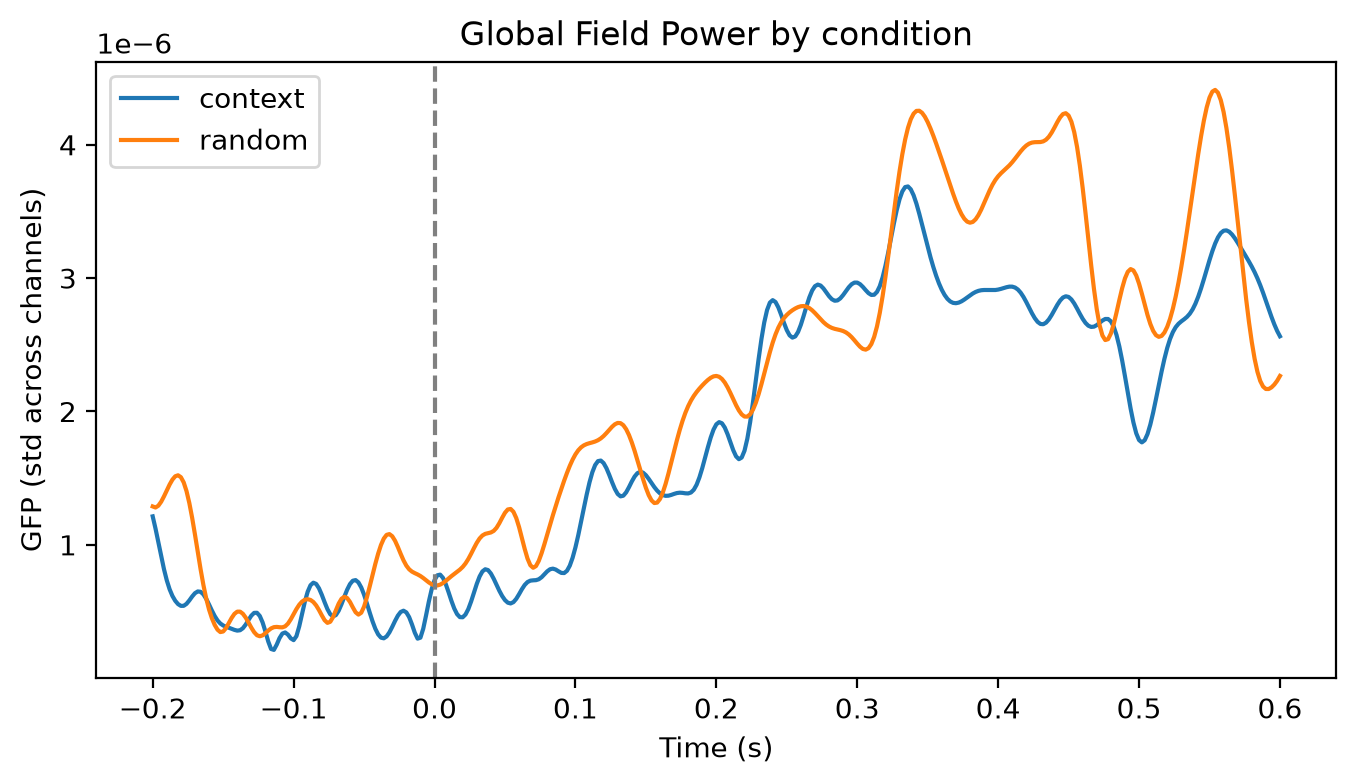

In [11]:
fig_gfp, ax = plt.subplots(figsize=(8, 4))

for label, cond_epochs in [('context', epochs_context), ('random', epochs_random)]:
    evoked_cond = cond_epochs.copy().crop(tmin=config['aep']['crop_tmin'], tmax=config['aep']['crop_tmax']).average()
    gfp = evoked_cond.data.std(axis=0)
    ax.plot(evoked_cond.times, gfp, label=label)

ax.set_title('Global Field Power by condition')
ax.set_xlabel('Time (s)')
ax.set_ylabel('GFP (std across channels)')
ax.axvline(0, linestyle='--', color='gray')
ax.legend()

save_fig(fig_gfp, 'gfp_by_condition')
fig_gfp

## (d) Performing time-frequency analysis of epochs

In this step, a **time-frequency analysis** (TFR) is performed on the epochs using the **Morlet wavelet transform**. TFR provides insight into how power at different frequencies evolves over time, offering a more detailed view of the dynamics of neural responses compared to standard time-domain analyses.

Unlike the AEP step above, this analysis uses the **full-length epochs** from step (a) rather than a cropped version — low-frequency wavelets need a longer time window to resolve, so shortening the epoch here would degrade frequency resolution at the low end.

### Explanation of the parameters (`config['tfr']`)

- **`freqs`**: Specifies the frequencies of interest for the analysis, built from `freq_min`/`freq_max`/`n_freqs`. In this example, frequencies between 1 Hz and 30 Hz are analyzed, using a total of 30 frequency steps.
- **`n_cycles`**: Determines the number of cycles in each Morlet wavelet. A value of 3 ensures a good balance between time and frequency resolution. Higher values provide better frequency resolution but worse temporal resolution.
- **`method='morlet'`**: Indicates that the Morlet wavelet transform is used for the TFR computation. This is one of the most common methods for EEG time-frequency analyses.
- **`return_itc=False`**: Specifies that only the power of the signal is of interest, not the inter-trial coherence (ITC).
- **`average=True`**: Averages the TFR across all epochs to obtain a single power estimate for each time-frequency point.

In [12]:
# Define frequencies and resolution from config.json, but this can be more fine-grained if needed
tfr_cfg = config['tfr']
frequencies = np.linspace(tfr_cfg['freq_min'], tfr_cfg['freq_max'], tfr_cfg['n_freqs'])
n_cycles = tfr_cfg['n_cycles']

logger.info(f"Computing TFR: {tfr_cfg['freq_min']}-{tfr_cfg['freq_max']} Hz, {tfr_cfg['n_freqs']} steps, n_cycles={n_cycles}")

# Compute time-frequency representation
power = epochs.compute_tfr(
    method='morlet',
    freqs=frequencies,
    return_itc=False,
    n_cycles=n_cycles,
    average=True
)

INFO - Computing TFR: 1-30 Hz, 30 steps, n_cycles=3


### Visualizing time-frequency analysis results

To explore the time-frequency representation of the data, `power.plot_topo()` is used to visualize the power of frequencies across time for each electrode channel. This visualization provides an overview of how power at different frequencies evolves over time across the scalp.

#### Interactive plot

In this plot:
- Each subplot corresponds to an individual electrode channel.
- You can **click on any subplot** to view a larger, more detailed time-frequency representation for that specific channel.

#### Observations

Typically, you would observe:
- An increase in power in the **5–10 Hz frequency range** after speech onset, which is expected based on neural activity related to speech processing.
- Limited resolution for frequencies below 4 Hz due to the relatively short epoch duration.

#### Use cases for time-frequency data

The time-frequency data can be used for various analyses, such as:
- **Condition-based comparisons**: Analyzing power differences in specific frequency bands (e.g., delta, theta, alpha) between conditions, such as "random" vs. "context."
- **Group-level comparisons**: Investigating differences in power between experimental groups, such as younger vs. older adults, or groups with varying degrees of hearing loss.
- **Regions of interest (ROI) analysis**: Focusing on specific clusters of electrodes to study localized neural activity in predefined regions of interest (e.g., frontal, central, or parietal regions).

#### Customizing frequency resolution

The resolution of the time-frequency analysis can be adjusted by modifying the `freqs` parameter in the TFR computation step. Higher resolution allows for more detailed frequency analysis but may increase computational cost.

In [13]:
fig_tfr = power.plot_topo(
    title='Power of frequencies across time for each electrode channel',
    baseline=(-0.200, 0),
    mode='logratio',
    vmin=-1,
    vmax=1,
    cmap='coolwarm'
)
save_fig(fig_tfr, 'tfr_topo')

Applying baseline correction (mode: logratio)


INFO - Saved figure 'tfr_topo' to figures/p34_tfr_topo.png


[PosixPath('figures/p34_tfr_topo.png')]

### Storing time-frequency power data for further analysis

This step demonstrates how to save the time-frequency power data for future analyses. The power data is converted into a **DataFrame**, making it easy to inspect and manipulate. Each row corresponds to a time point, and columns include frequencies and channel information.

### Steps:
1. **Convert power data to a DataFrame**:
   - The `.to_data_frame()` method is used to convert the `power` object into a pandas DataFrame. This format is flexible and well-suited for further processing in Python or external software.

2. **Set time as the index**:
   - The `time` column is set as the index to make the data easier to navigate, especially for time-based analyses.

3. **Save the DataFrame to a `.csv` file**:
   - The data is stored as a `.csv` file for portability. This ensures the power data can be used in other environments or tools.

In [14]:
# Create a DataFrame with the power data
power_df = power.to_data_frame()

# Make column 'times' the index
power_df.set_index('time', inplace=True)

# Store the power data in a .csv file
power_csv_path = analyses_folder / f"{participant_stem}_power_data.csv"
power_df.to_csv(power_csv_path)
logger.info(f"Saved power data to {power_csv_path}")

power_df.head(5)

INFO - Saved power data to analyses/p34_power_data.csv


,freq,Fp1,AF3,F7,F3,FC1,FC5,T7,C3,CP1,...,C4,T8,FC6,FC2,F4,F8,AF4,Fp2,Fz,Cz
time,,,,,,,,,,,,,,,,,,,,,
-0.200,1.0,3.917679e-09,8.518619e-10,8.411111e-10,3.792362e-10,1.290026e-09,1.635879e-10,9.032026e-11,1.524159e-09,3.612370e-09,...,1.729032e-09,3.478648e-10,4.444730e-10,2.864676e-09,4.916971e-10,3.005058e-10,9.114493e-10,4.506324e-09,1.289517e-09,1.856528e-08
-0.198,1.0,3.942604e-09,8.571225e-10,8.464067e-10,3.817729e-10,1.298870e-09,1.646869e-10,9.094843e-11,1.534506e-09,3.638716e-09,...,1.741192e-09,3.503575e-10,4.477675e-10,2.886941e-09,4.952544e-10,3.026174e-10,9.169788e-10,4.535076e-09,1.298705e-09,1.871134e-08
-0.196,1.0,3.967556e-09,8.623864e-10,8.517068e-10,3.843146e-10,1.307735e-09,1.657881e-10,9.157817e-11,1.544876e-09,3.665142e-09,...,1.753385e-09,3.528575e-10,4.510730e-10,2.909293e-09,4.988225e-10,3.047346e-10,9.225106e-10,4.563861e-09,1.307918e-09,1.885799e-08
-0.194,1.0,3.992534e-09,8.676533e-10,8.570111e-10,3.868613e-10,1.316621e-09,1.668915e-10,9.220947e-11,1.555269e-09,3.691647e-09,...,1.765612e-09,3.553647e-10,4.543895e-10,2.931729e-09,5.024015e-10,3.068573e-10,9.280446e-10,4.592678e-09,1.317156e-09,1.900523e-08
-0.192,1.0,4.017537e-09,8.729229e-10,8.623192e-10,3.894127e-10,1.325527e-09,1.679970e-10,9.284228e-11,1.565685e-09,3.718231e-09,...,1.777871e-09,3.578790e-10,4.577168e-10,2.954250e-09,5.059911e-10,3.089856e-10,9.335802e-10,4.621526e-09,1.326419e-09,1.915305e-08


## (e) Generating an analysis report

As in notebook 1, `mne.Report` bundles the key outputs of this run — the epochs summary, the AEP, the GFP condition comparison, and the TFR topo plot — into one self-contained HTML file, saved to `config['paths']['reports_folder']`.

In [15]:
reports_folder = Path(config['paths']['reports_folder'])
reports_folder.mkdir(exist_ok=True)

report = mne.Report(title=f"EEG analysis report — {participant_filename}")
report.add_epochs(epochs=epochs, title='Epochs')
report.add_evokeds(evokeds=evoked, titles='AEP (all conditions)')
report.add_figure(fig_joint, title='AEP joint plot')
report.add_figure(fig_gfp, title='GFP by condition')
report.add_figure(fig_tfr, title='Time-frequency power (topo)')

report_path = reports_folder / f"{participant_stem}_analysis_report.html"
report.save(report_path, overwrite=True)

logger.info(f"Saved analysis report to {report_path}")

Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : bootstrap-table/bootstrap-table-copy-rows.min.js
Embedding : bootstrap-table/bootstrap-table-export.min.js
Embedding : bootstrap-table/tableExport.min.js
Embedding : bootstrap-icons/bootstrap-icons.mne.min.css
Embedding : highlightjs/highlight.min.js
Embedding : highlightjs/atom-one-dark-reasonable.min.css
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Saving report to : /Users/bsertc/Desktop/NeuroPipe/reports/p34_analysis_report.html


INFO - Saved analysis report to reports/p34_analysis_report.html
